<div style="background: linear-gradient(135deg, #4E2A84 0%, #836EAA 100%); padding: 30px; border-radius: 10px; color: white; box-shadow: 0 4px 6px rgba(0,0,0,0.15); font-family: Arial, sans-serif;">

<h1 style="margin: 0; color: white; text-align: center;">
Analysis of U.S. Airline Operational Performance
</h1>

<h3 style="margin: 10px 0 0 0; color: #E6E6E6; text-align: center; font-weight: normal;">
Exploratory Data Analysis | 2023–2025
</h3>

</div>

<div style="text-align: center; margin-top: 18px; color: #4E2A84; font-family: Arial, sans-serif; line-height: 1.6;">

<strong>Team 1:</strong> Sara Alsiyat • Prathamesh Nehete • Yedong Deng<br>
<strong>Course:</strong> MSDS 420 – Database Systems | Dr. Abid Ali<br>
<strong>Institution:</strong> Northwestern University | February 2026

</div>

<div style="background-color: #4E2A84; color: white; padding: 18px; border-radius: 8px; margin-top: 18px; font-family: Arial, sans-serif;">

<h3 style="margin: 0; color: white;">
Understanding Flight Delays, Operational Efficiency, and Business Impact
</h3>

</div>


## Table of Contents

1. [Executive Summary](#1-executive-summary)
2. [Purpose and Objectives](#2-purpose-and-objectives)
3. [Data Sources Overview](#3-data-sources-overview)
4. [Flight Volume Analysis](#4-flight-volume-analysis)
5. [Airline Performance Analysis](#5-airline-performance-analysis)
6. [Airport Operations Analysis](#6-airport-operations-analysis)
7. [Delay Analysis](#7-delay-analysis)
8. [Holiday Impact Analysis](#8-holiday-impact-analysis)
9. [Financial Performance & Fuel Prices](#9-financial-performance--fuel-prices)
10. [Data Quality Assessment](#10-data-quality-assessment)
11. [Key Findings and Insights](#11-key-findings-and-insights)
12. [Next Steps: Database Design](#12-next-steps-database-design)

---
## 1. Executive Summary

This Exploratory Data Analysis (EDA) investigates U.S. domestic flight operations using data from the Bureau of Transportation Statistics (BTS). Our analysis integrates **six data sources** to provide a comprehensive view of airline performance, operational efficiency, and business impact.

### The Story We're Telling

> **"Why are flights delayed, who is responsible, and what does it cost?"**

This analysis will answer:
1. **What** is the current state of U.S. airline on-time performance?
2. **When** do delays happen most frequently (time of day, day of week, holidays)?
3. **Why** do delays occur (controllable vs. uncontrollable causes)?
4. **Who** performs best among airlines and airports?
5. **How much** do delays cost (fuel, operations, customer impact)?

### Data Sources Integrated

| # | Source | Table | Records | Purpose |
|---|--------|-------|---------|--------|
| 1 | BTS | stg_ontime | ~20M | Flight-level performance |
| 2 | BTS | stg_airport_reference | ~400 | Airport attributes |
| 3 | BTS | stg_airport_traffic | ~24K | Monthly operations |
| 4 | BTS | stg_financial | ~1K | Airline financials |
| 5 | OPM | stg_us_holidays | ~50 | Holiday calendar |
| 6 | EIA | stg_jet_fuel_prices | ~35 | Fuel cost data |

---
## 2. Purpose and Objectives

### 2.1 Project Purpose

This EDA serves as the **foundation for a comprehensive database systems project** demonstrating:

1. **Data Integration:** Combining 6 authoritative data sources
2. **Database Design:** Creating normalized schemas (3NF, Star, Snowflake)
3. **Analytical Capabilities:** Supporting operational and strategic decision-making
4. **Real-World Application:** Addressing actual business problems in aviation

### 2.2 Business Questions

**For Airlines:**
- Which airports have higher average delay rates?
- Are delay causes controllable (carrier) or uncontrollable (weather)?
- How can controllable delays be eliminated?

**For Airports:**
- Which airlines are most likely to have delays?
- Is weather a key factor in causing delays?
- How can air traffic control be optimized?

**New Questions (with additional data sources):**
- Are delays worse during major holidays?
- Do fuel prices impact airline service quality?
- What is the financial cost of operational delays?

In [1]:
# ============================================================================
# SETUP AND CONFIGURATION
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

# Northwestern University Brand Colors
NU_PURPLE = "#4E2A84"
NU_LIGHT_PURPLE = "#B6ACD1"
NU_GRAY = "#E6E6E6"
NU_DARK_GRAY = "#716C6B"
NU_WHITE = "#FFFFFF"

# Color palette for charts
NU_PALETTE = [NU_PURPLE, NU_LIGHT_PURPLE, NU_DARK_GRAY, "#E4E0EE", "#836EAA"]

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette(NU_PALETTE)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("✅ Libraries imported successfully")
print(f"📅 Analysis Date: {datetime.now().strftime('%B %d, %Y')}")

✅ Libraries imported successfully
📅 Analysis Date: February 16, 2026


In [2]:
# ============================================================================
# DATABASE CONNECTION
# ============================================================================

# Update these credentials for your environment
DB_CONFIG = {
    'user': 'root',
    'password': 'mysql123',  
    'host': 'localhost',
    'database': 'staging_db'
}

# Create database connection
connection_string = f"mysql+pymysql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}/{DB_CONFIG['database']}"
engine = create_engine(connection_string, pool_pre_ping=True)

# Test connection
try:
    with engine.connect() as conn:
        result = conn.execute(text("SELECT 1"))
    print("✅ Database connection established successfully!")
    print(f"📊 Connected to: {DB_CONFIG['database']}")
except Exception as e:
    print(f"❌ Connection failed: {e}")

✅ Database connection established successfully!
📊 Connected to: staging_db


In [3]:
# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def nu_style_table(df, caption=None):
    """Apply Northwestern-styled formatting to a DataFrame."""
    styled = df.style.set_table_styles([
        {'selector': 'th', 'props': [('background-color', NU_PURPLE), ('color', 'white'), 
                                      ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('background-color', NU_GRAY), ('text-align', 'center'), ('padding', '6px')]},
        {'selector': 'table', 'props': [('width', '100%'), ('margin', '0 auto'), ('border-collapse', 'collapse')]},
    ])
    if caption:
        styled = styled.set_caption(caption).set_table_styles(
            [{'selector': 'caption', 'props': [('caption-side', 'top'), ('font-weight', 'bold'),
                                                ('font-size', '14px'), ('text-align', 'center'), ('padding-bottom', '6px')]}],
            overwrite=False
        )
    return styled

def format_number(num):
    """Format large numbers with commas."""
    if pd.isna(num):
        return "N/A"
    return f"{num:,.0f}"

def format_pct(num):
    """Format percentage."""
    if pd.isna(num):
        return "N/A"
    return f"{num:.2f}%"

def create_donut_chart(data, labels, title, colors=None):
    """Create a donut chart with Northwestern styling."""
    if colors is None:
        colors = NU_PALETTE[:len(data)]
    
    fig, ax = plt.subplots(figsize=(8, 8))
    wedges, texts, autotexts = ax.pie(data, labels=labels, autopct='%1.1f%%',
                                       colors=colors, startangle=90,
                                       wedgeprops=dict(width=0.5, edgecolor='white'))
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    ax.set_title(title, fontsize=16, fontweight='bold', color=NU_PURPLE, pad=20)
    plt.tight_layout()
    return fig

print("✅ Helper functions defined")

✅ Helper functions defined


---
## 3. Data Sources Overview

Let's explore each of our **6 staging tables** to understand the data we're working with.

In [4]:
# ============================================================================
# DATA SOURCES OVERVIEW
# ============================================================================

# Get record counts for all staging tables
tables_query = """
SELECT 'stg_ontime' AS table_name, COUNT(*) AS record_count FROM stg_ontime
UNION ALL SELECT 'stg_airport_reference', COUNT(*) FROM stg_airport_reference
UNION ALL SELECT 'stg_airport_traffic', COUNT(*) FROM stg_airport_traffic
UNION ALL SELECT 'stg_financial', COUNT(*) FROM stg_financial
UNION ALL SELECT 'stg_us_holidays', COUNT(*) FROM stg_us_holidays
UNION ALL SELECT 'stg_jet_fuel_prices', COUNT(*) FROM stg_jet_fuel_prices
"""

df_tables = pd.read_sql(tables_query, engine)
df_tables['record_count_fmt'] = df_tables['record_count'].apply(format_number)

# Add descriptions
descriptions = {
    'stg_ontime': 'Flight-level on-time performance data',
    'stg_airport_reference': 'Airport master data with locations',
    'stg_airport_traffic': 'Monthly airport traffic statistics',
    'stg_financial': 'Quarterly airline financial reports',
    'stg_us_holidays': 'U.S. federal and major holidays',
    'stg_jet_fuel_prices': 'Monthly jet fuel price data'
}
sources = {
    'stg_ontime': 'BTS',
    'stg_airport_reference': 'BTS',
    'stg_airport_traffic': 'BTS',
    'stg_financial': 'BTS Form 41',
    'stg_us_holidays': 'OPM',
    'stg_jet_fuel_prices': 'EIA'
}

df_tables['description'] = df_tables['table_name'].map(descriptions)
df_tables['source'] = df_tables['table_name'].map(sources)

print("\n" + "="*70)
print("📊 DATA SOURCES SUMMARY")
print("="*70)

display(nu_style_table(
    df_tables[['table_name', 'source', 'record_count_fmt', 'description']].rename(
        columns={'table_name': 'Table', 'source': 'Source', 'record_count_fmt': 'Records', 'description': 'Description'}
    ),
    caption="Staging Tables Overview"
))

total_records = df_tables['record_count'].sum()
print(f"\n📈 Total Records Across All Sources: {format_number(total_records)}")


📊 DATA SOURCES SUMMARY


,Table,Source,Records,Description
0,stg_ontime,BTS,"19,775,745",Flight-level on-time performance data
1,stg_airport_reference,BTS,361,Airport master data with locations
2,stg_airport_traffic,BTS,"11,481",Monthly airport traffic statistics
3,stg_financial,BTS Form 41,960,Quarterly airline financial reports
4,stg_us_holidays,OPM,48,U.S. federal and major holidays
5,stg_jet_fuel_prices,EIA,34,Monthly jet fuel price data



📈 Total Records Across All Sources: 19,788,629


In [5]:
# ============================================================================
# EXPLORE: stg_ontime (Main Flight Data) - Correct Delay Logic
# ============================================================================

print("\n" + "="*70)
print("✈️ stg_ontime - FLIGHT PERFORMANCE DATA")
print("="*70)

ontime_stats = pd.read_sql("""
SELECT 
    COUNT(*) AS total_flights,
    COUNT(DISTINCT OP_UNIQUE_CARRIER) AS airlines,
    COUNT(DISTINCT ORIGIN) AS origin_airports,
    COUNT(DISTINCT DEST) AS dest_airports,
    MIN(FL_DATE) AS date_from,
    MAX(FL_DATE) AS date_to,

    -- Cancelled flights
    SUM(CASE WHEN CAST(CANCELLED AS UNSIGNED) = 1 THEN 1 ELSE 0 END) AS cancelled_flights,

    -- Delayed flights: ARR_DELAY > 15 (exclude cancelled)
    SUM(CASE 
            WHEN CAST(CANCELLED AS UNSIGNED) = 0 
             AND CAST(ARR_DELAY AS SIGNED) > 15 THEN 1 
            ELSE 0 
        END) AS delayed_flights

FROM stg_ontime
""", engine)

total_flights = int(ontime_stats["total_flights"].iloc[0])
cancelled = int(ontime_stats["cancelled_flights"].iloc[0])
delayed = int(ontime_stats["delayed_flights"].iloc[0])
on_time = total_flights - cancelled - delayed

print(f"\n📊 Key Statistics:")
print(f"   • Total Flights: {format_number(total_flights)}")
print(f"   • Airlines: {ontime_stats['airlines'].iloc[0]}")
print(f"   • Airports (origin): {ontime_stats['origin_airports'].iloc[0]}")
print(f"   • Date Range: {ontime_stats['date_from'].iloc[0]} to {ontime_stats['date_to'].iloc[0]}")

print(f"\n📈 Performance Summary (Using ARR_DELAY > 15):")
print(f"   • On-Time: {format_number(on_time)} ({on_time/total_flights*100:.2f}%)")
print(f"   • Delayed: {format_number(delayed)} ({delayed/total_flights*100:.2f}%)")
print(f"   • Cancelled: {format_number(cancelled)} ({cancelled/total_flights*100:.2f}%)")

# Flag Distribution Check (keep it, but it proves ARR_DEL15 isn't binary)
print("\n🔍 Flag Distribution Check (ARR_DEL15 values):")
flag_check = pd.read_sql("""
SELECT ARR_DEL15, COUNT(*) AS n
FROM stg_ontime
GROUP BY ARR_DEL15
ORDER BY n DESC
LIMIT 15;
""", engine)

display(nu_style_table(flag_check, "ARR_DEL15 Value Distribution"))



✈️ stg_ontime - FLIGHT PERFORMANCE DATA

📊 Key Statistics:
   • Total Flights: 19,775,745
   • Airlines: 15
   • Airports (origin): 361
   • Date Range: 1/1/2023 12:00:00 AM to 9/9/2025 12:00:00 AM

📈 Performance Summary (Using ARR_DELAY > 15):
   • On-Time: 15,540,537 (78.58%)
   • Delayed: 3,971,270 (20.08%)
   • Cancelled: 263,938 (1.33%)

🔍 Flag Distribution Check (ARR_DEL15 values):


,ARR_DEL15,n
0,0.00,15356908
1,1.00,4104026
2,,314811


In [6]:
# ============================================================================
# EXPLORE: stg_airport_reference
# ============================================================================

print("\n" + "="*70)
print("🛫 stg_airport_reference - AIRPORT MASTER DATA")
print("="*70)

df_airports = pd.read_sql("SELECT * FROM stg_airport_reference", engine)

print(f"\n📊 Columns: {list(df_airports.columns)}")
print(f"\n📍 Airports by Region:")

region_counts = df_airports['region'].value_counts()
for region, count in region_counts.items():
    print(f"   • {region}: {count} airports")

print(f"\n🏢 Airports by Hub Type:")
hub_counts = df_airports['hub_type'].value_counts()
for hub, count in hub_counts.items():
    print(f"   • {hub}: {count} airports")


🛫 stg_airport_reference - AIRPORT MASTER DATA

📊 Columns: ['airport_id', 'airport_code', 'airport_name', 'city', 'state_code', 'state_name', 'region', 'hub_type', 'load_timestamp']

📍 Airports by Region:
   • South: 113 airports
   • West: 111 airports
   • Midwest: 88 airports
   • Northeast: 41 airports
   • Other: 8 airports

🏢 Airports by Hub Type:
   • Nonhub: 197 airports
   • Small Hub: 116 airports
   • Medium Hub: 40 airports
   • Large Hub: 8 airports


In [7]:
# ============================================================================
# EXPLORE: stg_us_holidays (NEW DATA SOURCE)
# ============================================================================

print("\n" + "="*70)
print("🎄 stg_us_holidays - HOLIDAY CALENDAR")
print("="*70)

df_holidays = pd.read_sql("SELECT * FROM stg_us_holidays", engine)

print(f"\n📊 Total Holidays: {len(df_holidays)}")
print(f"📅 Years Covered: {df_holidays['year'].min()} - {df_holidays['year'].max()}")

print(f"\n🎯 Holiday Types:")
for htype, count in df_holidays['holiday_type'].value_counts().items():
    print(f"   • {htype}: {count}")

major_travel = df_holidays[df_holidays['is_major_travel'].astype(str).str.upper() == 'TRUE']
print(f"\n✈️ Major Travel Holidays ({len(major_travel)}):")
for _, row in major_travel.head(10).iterrows():
    print(f"   • {row['holiday_name']}")


🎄 stg_us_holidays - HOLIDAY CALENDAR

📊 Total Holidays: 48
📅 Years Covered: 2023 - 2025

🎯 Holiday Types:
   • Federal: 33
   • Observance: 9
   • Religious: 3
   • Commercial: 3

✈️ Major Travel Holidays (33):
   • New Year's Day
   • Presidents Day
   • Easter Sunday
   • Memorial Day
   • Independence Day
   • Labor Day
   • Thanksgiving
   • Black Friday
   • Christmas Eve
   • Christmas Day



⛽ stg_jet_fuel_prices - FUEL COST DATA

📊 Data Points: 34 months
📅 Period: 2023-01 to 2025-12

💰 Price Statistics ($/gallon):
   • Minimum: $2.65
   • Maximum: $3.28
   • Average: $2.90


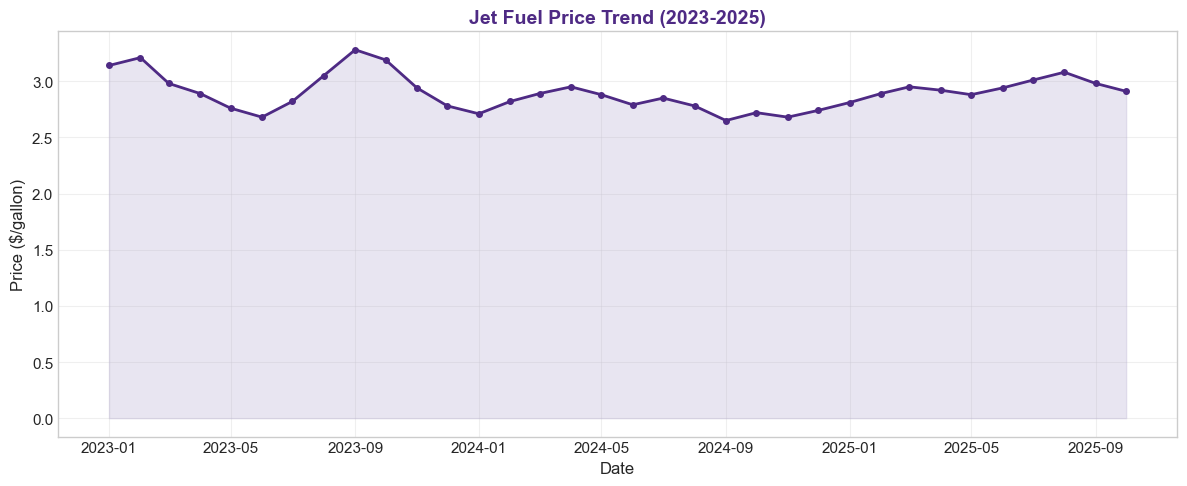

In [8]:
# ============================================================================
# EXPLORE: stg_jet_fuel_prices (NEW DATA SOURCE)
# ============================================================================

print("\n" + "="*70)
print("⛽ stg_jet_fuel_prices - FUEL COST DATA")
print("="*70)

df_fuel = pd.read_sql("SELECT * FROM stg_jet_fuel_prices ORDER BY year, month", engine)

df_fuel['jet_fuel_price_per_gallon'] = pd.to_numeric(df_fuel['jet_fuel_price_per_gallon'], errors='coerce')

print(f"\n📊 Data Points: {len(df_fuel)} months")
print(f"📅 Period: {df_fuel['year'].min()}-{df_fuel['month'].min():02d} to {df_fuel['year'].max()}-{df_fuel['month'].max():02d}")
print(f"\n💰 Price Statistics ($/gallon):")
print(f"   • Minimum: ${df_fuel['jet_fuel_price_per_gallon'].min():.2f}")
print(f"   • Maximum: ${df_fuel['jet_fuel_price_per_gallon'].max():.2f}")
print(f"   • Average: ${df_fuel['jet_fuel_price_per_gallon'].mean():.2f}")

# Plot fuel prices
fig, ax = plt.subplots(figsize=(12, 5))
df_fuel['date'] = pd.to_datetime(df_fuel['year'].astype(str) + '-' + df_fuel['month'].astype(str) + '-01')
ax.plot(df_fuel['date'], df_fuel['jet_fuel_price_per_gallon'], color=NU_PURPLE, linewidth=2, marker='o', markersize=4)
ax.fill_between(df_fuel['date'], df_fuel['jet_fuel_price_per_gallon'], alpha=0.3, color=NU_LIGHT_PURPLE)
ax.set_title('Jet Fuel Price Trend (2023-2025)', fontsize=14, fontweight='bold', color=NU_PURPLE)
ax.set_xlabel('Date')
ax.set_ylabel('Price ($/gallon)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. Flight Volume Analysis

Understanding flight volume patterns by time (year, month, day of week) helps identify peak periods and seasonal trends.

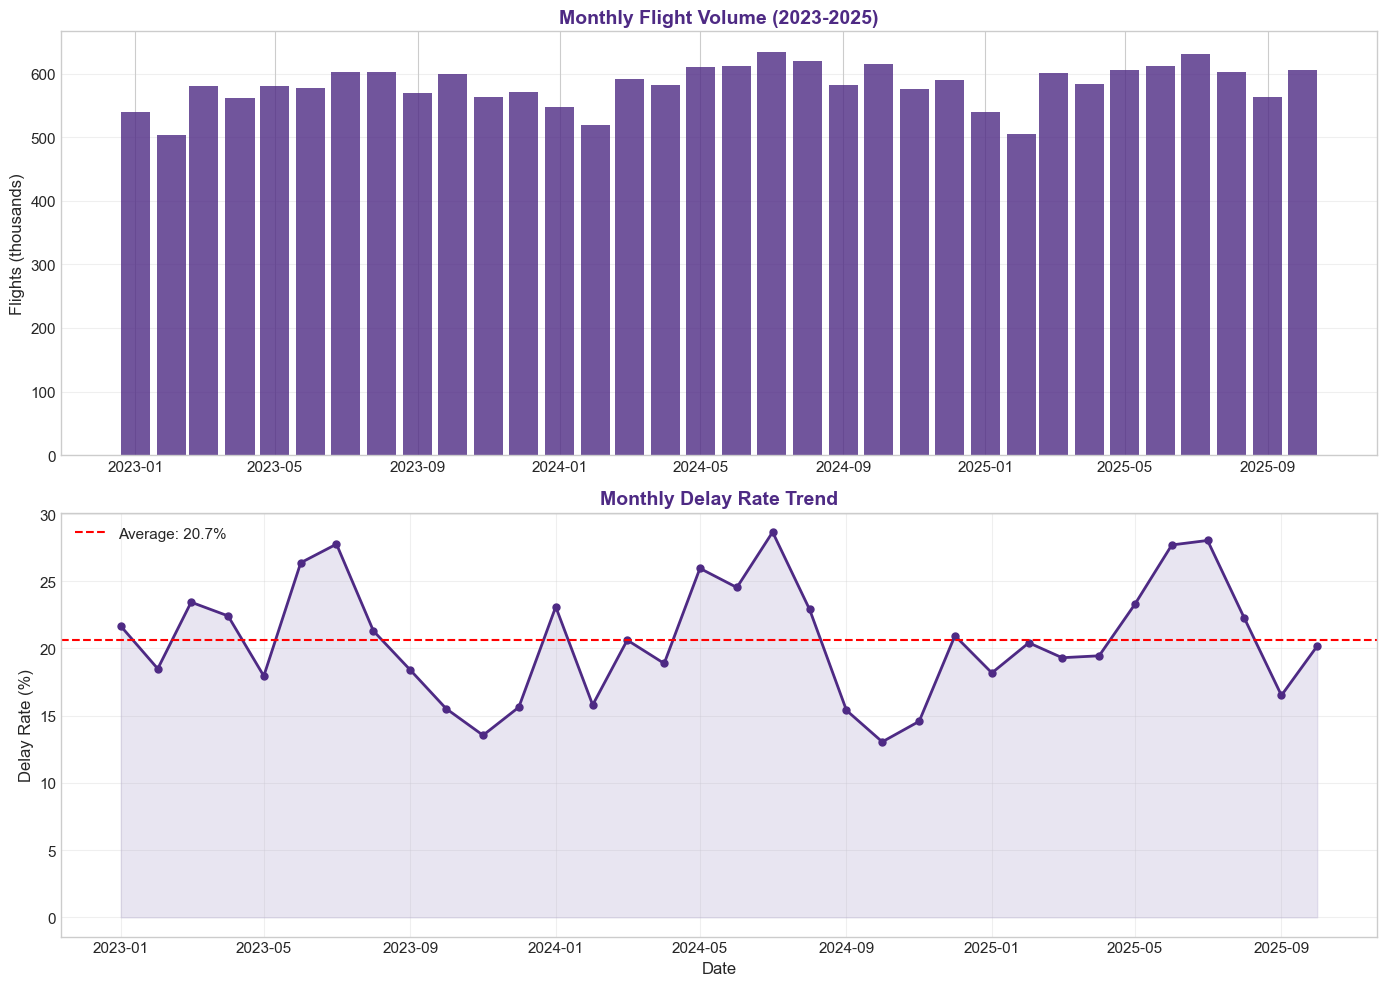


📊 Key Insights:
   • Average Monthly Flights: 581,640
   • Average Delay Rate: 20.65%
   • Highest Delay Month: July 2024 (28.66%)
   • Lowest Delay Month: October 2024 (13.05%)


In [9]:
volume_query = """
SELECT 
    YEAR AS year,
    MONTH AS month,
    COUNT(*) AS total_flights,
    SUM(CASE WHEN CAST(ARR_DEL15 AS UNSIGNED) = 1 THEN 1 ELSE 0 END) AS delayed_flights,
    SUM(CASE WHEN CAST(CANCELLED AS UNSIGNED) = 1 THEN 1 ELSE 0 END) AS cancelled_flights
FROM stg_ontime
GROUP BY YEAR, MONTH
ORDER BY YEAR, MONTH
"""

df_volume = pd.read_sql(volume_query, engine)

# Metrics
df_volume["delay_rate"] = df_volume["delayed_flights"] / df_volume["total_flights"] * 100
df_volume["date"] = pd.to_datetime(df_volume["year"].astype(str) + "-" + df_volume["month"].astype(str) + "-01")
df_volume["month_name"] = df_volume["date"].dt.strftime("%b")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Flight volume
ax1 = axes[0]
ax1.bar(df_volume["date"], df_volume["total_flights"] / 1000,
        color=NU_PURPLE, alpha=0.8, width=25)
ax1.set_title("Monthly Flight Volume (2023-2025)",
              fontsize=14, fontweight="bold", color=NU_PURPLE)
ax1.set_ylabel("Flights (thousands)")
ax1.grid(axis="y", alpha=0.3)

# Delay rate
ax2 = axes[1]
ax2.plot(df_volume["date"], df_volume["delay_rate"],
         color=NU_PURPLE, linewidth=2, marker="o", markersize=5)

ax2.axhline(y=df_volume["delay_rate"].mean(),
            color="red", linestyle="--",
            label=f'Average: {df_volume["delay_rate"].mean():.1f}%')

ax2.fill_between(df_volume["date"],
                 df_volume["delay_rate"],
                 alpha=0.3,
                 color=NU_LIGHT_PURPLE)

ax2.set_title("Monthly Delay Rate Trend",
              fontsize=14, fontweight="bold", color=NU_PURPLE)
ax2.set_ylabel("Delay Rate (%)")
ax2.set_xlabel("Date")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Key Insights:")
print(f"   • Average Monthly Flights: {format_number(df_volume['total_flights'].mean())}")
print(f"   • Average Delay Rate: {df_volume['delay_rate'].mean():.2f}%")
print(f"   • Highest Delay Month: {df_volume.loc[df_volume['delay_rate'].idxmax(), 'date'].strftime('%B %Y')} ({df_volume['delay_rate'].max():.2f}%)")
print(f"   • Lowest Delay Month: {df_volume.loc[df_volume['delay_rate'].idxmin(), 'date'].strftime('%B %Y')} ({df_volume['delay_rate'].min():.2f}%)")


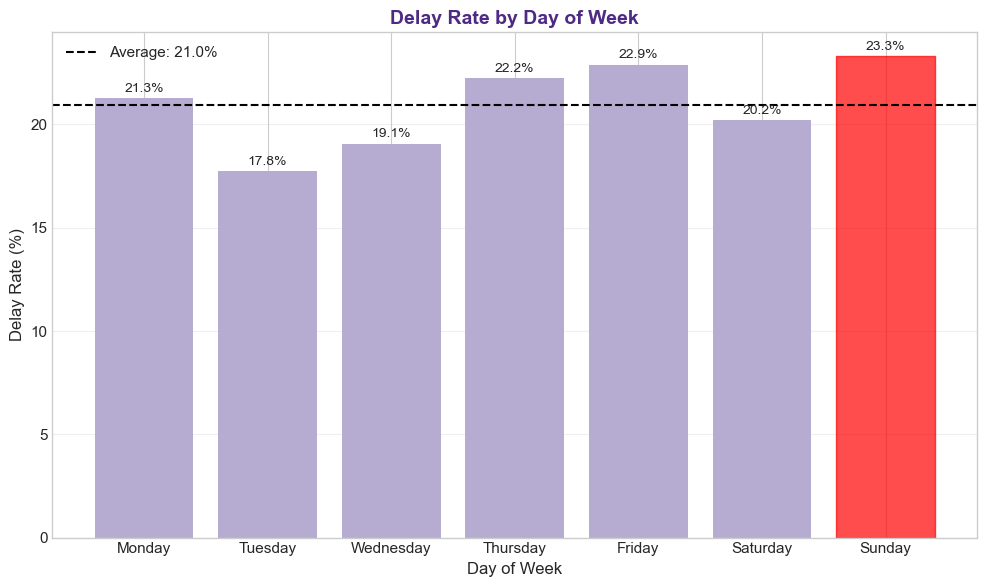


📊 Day of Week Analysis:
   • Best Day to Fly: Tuesday (17.76% delay rate)
   • Worst Day to Fly: Sunday (23.29% delay rate)


In [10]:
# ============================================================================
# FLIGHT VOLUME BY DAY OF WEEK (FIXED + SAFE)
# ============================================================================

dow_query = """
SELECT 
    CAST(DAY_OF_WEEK AS UNSIGNED) AS day_of_week,
    COUNT(*) AS total_flights,

    -- robust delayed flag
    SUM(CASE WHEN CAST(ARR_DEL15 AS UNSIGNED) = 1 THEN 1 ELSE 0 END) AS delayed_flights,

    -- average delay minutes (exclude sentinel 999/-999)
    AVG(
        CASE 
            WHEN ARR_DELAY IS NULL THEN NULL
            WHEN CAST(ARR_DELAY AS SIGNED) IN (999, -999) THEN NULL
            ELSE CAST(ARR_DELAY AS SIGNED)
        END
    ) AS avg_delay

FROM stg_ontime
WHERE CAST(CANCELLED AS UNSIGNED) = 0
  AND DAY_OF_WEEK IS NOT NULL
GROUP BY CAST(DAY_OF_WEEK AS UNSIGNED)
ORDER BY CAST(DAY_OF_WEEK AS UNSIGNED)
"""

df_dow = pd.read_sql(dow_query, engine)

if df_dow.empty:
    print("⚠️ No rows returned for Day-of-Week analysis. Check DAY_OF_WEEK and CANCELLED values in stg_ontime.")
else:
    df_dow["delay_rate"] = df_dow["delayed_flights"] / df_dow["total_flights"] * 100

    day_names = {
        1: "Monday", 2: "Tuesday", 3: "Wednesday", 4: "Thursday",
        5: "Friday", 6: "Saturday", 7: "Sunday"
    }
    df_dow["day_name"] = df_dow["day_of_week"].astype(int).map(day_names)

    # Plot (avoid custom colors array issues)
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(df_dow["day_name"], df_dow["delay_rate"], color=NU_LIGHT_PURPLE)

    # Highlight worst day safely
    worst_pos = df_dow["delay_rate"].values.argmax()
    bars[worst_pos].set_color("red")
    bars[worst_pos].set_alpha(0.7)

    ax.axhline(
        y=df_dow["delay_rate"].mean(),
        color="black",
        linestyle="--",
        label=f'Average: {df_dow["delay_rate"].mean():.1f}%'
    )

    ax.set_title("Delay Rate by Day of Week", fontsize=14, fontweight="bold", color=NU_PURPLE)
    ax.set_ylabel("Delay Rate (%)")
    ax.set_xlabel("Day of Week")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    # Value labels
    for bar, val in zip(bars, df_dow["delay_rate"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val:.1f}%", ha="center", fontsize=10)

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Day of Week Analysis:")
    best_day = df_dow.loc[df_dow["delay_rate"].idxmin()]
    worst_day = df_dow.loc[df_dow["delay_rate"].idxmax()]
    print(f"   • Best Day to Fly: {best_day['day_name']} ({best_day['delay_rate']:.2f}% delay rate)")
    print(f"   • Worst Day to Fly: {worst_day['day_name']} ({worst_day['delay_rate']:.2f}% delay rate)")


---
## 5. Airline Performance Analysis

Benchmarking airlines by on-time performance, delay rates, and cancellation rates.

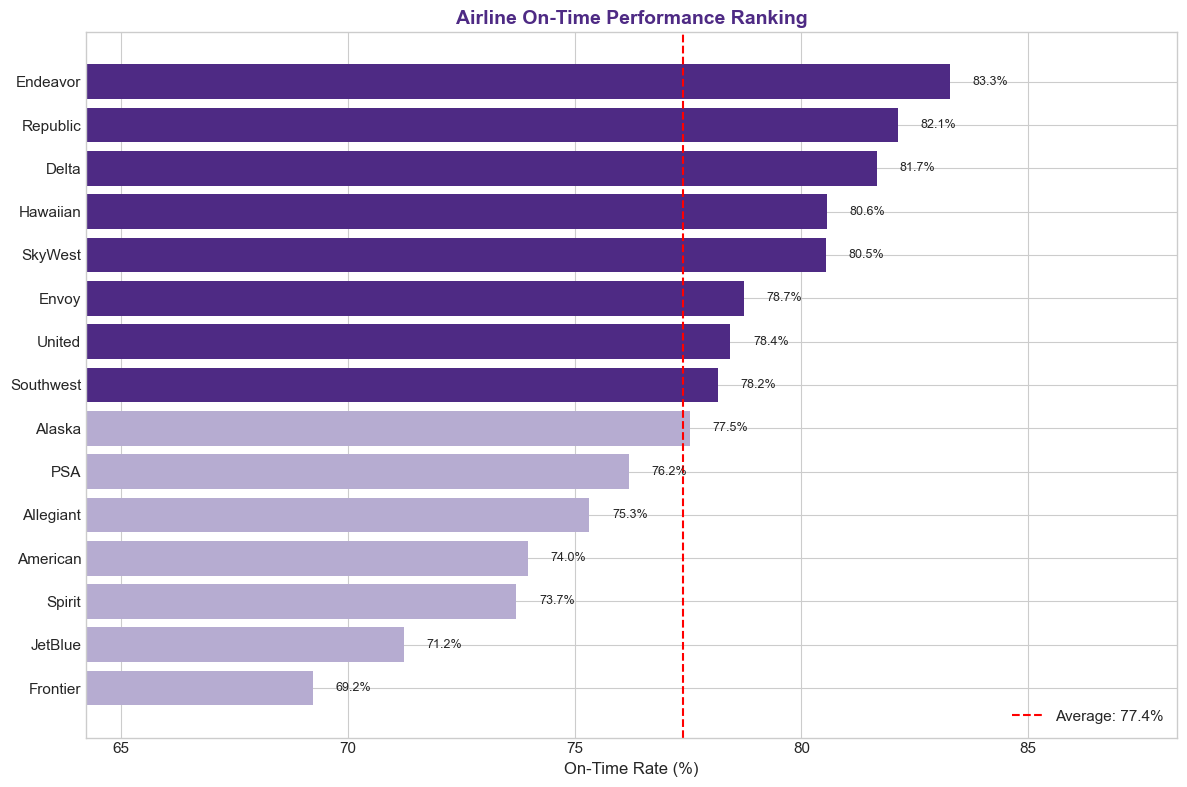


📊 Airline Performance Summary:


,Airline,Flights,On-Time %,Delay %,Cancel %,Avg Delay (min)
12,Endeavor,401614,83.280000,14.510000,2.200000,0.230000
5,Republic,883217,82.120000,15.330000,2.550000,-0.040000
1,Delta,2850898,81.660000,17.410000,0.930000,3.740000
14,Hawaiian,226450,80.570000,18.390000,1.040000,6.710000
4,SkyWest,2122481,80.550000,18.310000,1.150000,6.740000
6,Envoy,756645,78.730000,19.770000,1.500000,5.570000
3,United,2155378,78.430000,20.270000,1.300000,6.380000
0,Southwest,4017756,78.150000,20.970000,0.880000,5.610000
8,Alaska,695897,77.540000,21.140000,1.320000,3.920000
10,PSA,630599,76.190000,21.220000,2.580000,10.020000


In [11]:
# ============================================================================
# AIRLINE PERFORMANCE RANKING (FIXED)
# ============================================================================

airline_query = """
SELECT 
    OP_UNIQUE_CARRIER AS carrier,
    COUNT(*) AS total_flights,

    -- on-time = not cancelled AND not delayed (ARR_DEL15 = 0)
    SUM(CASE 
            WHEN CAST(CANCELLED AS UNSIGNED) = 0 
             AND CAST(ARR_DEL15 AS UNSIGNED) = 0
            THEN 1 ELSE 0 
        END) AS on_time,

    -- rename from "delayed" -> delayed_flights (avoid reserved word)
    SUM(CASE 
            WHEN CAST(CANCELLED AS UNSIGNED) = 0
             AND CAST(ARR_DEL15 AS UNSIGNED) = 1
            THEN 1 ELSE 0 
        END) AS delayed_flights,

    SUM(CASE WHEN CAST(CANCELLED AS UNSIGNED) = 1 THEN 1 ELSE 0 END) AS cancelled_flights,

    -- avg delay (exclude sentinel 999/-999 and cancelled flights)
    AVG(
        CASE 
            WHEN CAST(CANCELLED AS UNSIGNED) = 1 THEN NULL
            WHEN ARR_DELAY IS NULL THEN NULL
            WHEN CAST(ARR_DELAY AS SIGNED) IN (999, -999) THEN NULL
            ELSE CAST(ARR_DELAY AS SIGNED)
        END
    ) AS avg_delay

FROM stg_ontime
GROUP BY OP_UNIQUE_CARRIER
HAVING COUNT(*) > 10000
ORDER BY total_flights DESC
"""

df_airlines = pd.read_sql(airline_query, engine)

df_airlines["on_time_pct"] = df_airlines["on_time"] / df_airlines["total_flights"] * 100
df_airlines["delay_pct"] = df_airlines["delayed_flights"] / df_airlines["total_flights"] * 100
df_airlines["cancel_pct"] = df_airlines["cancelled_flights"] / df_airlines["total_flights"] * 100

# Carrier name mapping
carrier_names = {
    "AA": "American", "DL": "Delta", "UA": "United", "WN": "Southwest",
    "AS": "Alaska", "B6": "JetBlue", "NK": "Spirit", "F9": "Frontier",
    "G4": "Allegiant", "HA": "Hawaiian", "SY": "Sun Country",
    "MQ": "Envoy", "OH": "PSA", "OO": "SkyWest", "YX": "Republic", "9E": "Endeavor"
}
df_airlines["carrier_name"] = df_airlines["carrier"].map(carrier_names).fillna(df_airlines["carrier"])

# Sort by on-time performance for plot
df_airlines_sorted = df_airlines.sort_values("on_time_pct", ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
colors = [
    NU_PURPLE if x >= df_airlines["on_time_pct"].median() else NU_LIGHT_PURPLE
    for x in df_airlines_sorted["on_time_pct"]
]
bars = ax.barh(df_airlines_sorted["carrier_name"], df_airlines_sorted["on_time_pct"], color=colors)

ax.axvline(
    x=df_airlines["on_time_pct"].mean(),
    color="red",
    linestyle="--",
    label=f'Average: {df_airlines["on_time_pct"].mean():.1f}%'
)
ax.set_title("Airline On-Time Performance Ranking", fontsize=14, fontweight="bold", color=NU_PURPLE)
ax.set_xlabel("On-Time Rate (%)")
ax.legend(loc="lower right")

# Auto x-limits based on data (safer than hardcoding 50-90)
xmin = max(0, df_airlines_sorted["on_time_pct"].min() - 5)
xmax = min(100, df_airlines_sorted["on_time_pct"].max() + 5)
ax.set_xlim(xmin, xmax)

# Add value labels
for bar, val in zip(bars, df_airlines_sorted["on_time_pct"]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# Display table
print("\n📊 Airline Performance Summary:")
top10 = (
    df_airlines.sort_values("on_time_pct", ascending=False)[
        ["carrier_name", "total_flights", "on_time_pct", "delay_pct", "cancel_pct", "avg_delay"]
    ]
    .head(10)
    .round(2)
    .rename(columns={
        "carrier_name": "Airline",
        "total_flights": "Flights",
        "on_time_pct": "On-Time %",
        "delay_pct": "Delay %",
        "cancel_pct": "Cancel %",
        "avg_delay": "Avg Delay (min)"
    })
)

display(nu_style_table(top10, caption="Top 10 Airlines by On-Time Performance"))


Regional carriers like Endeavor and Republic show the highest on-time performance, suggesting tighter route networks and operational efficiency compared to large hub carriers.

---
## 6. Airport Operations Analysis

Analyzing airport-level performance and traffic patterns.

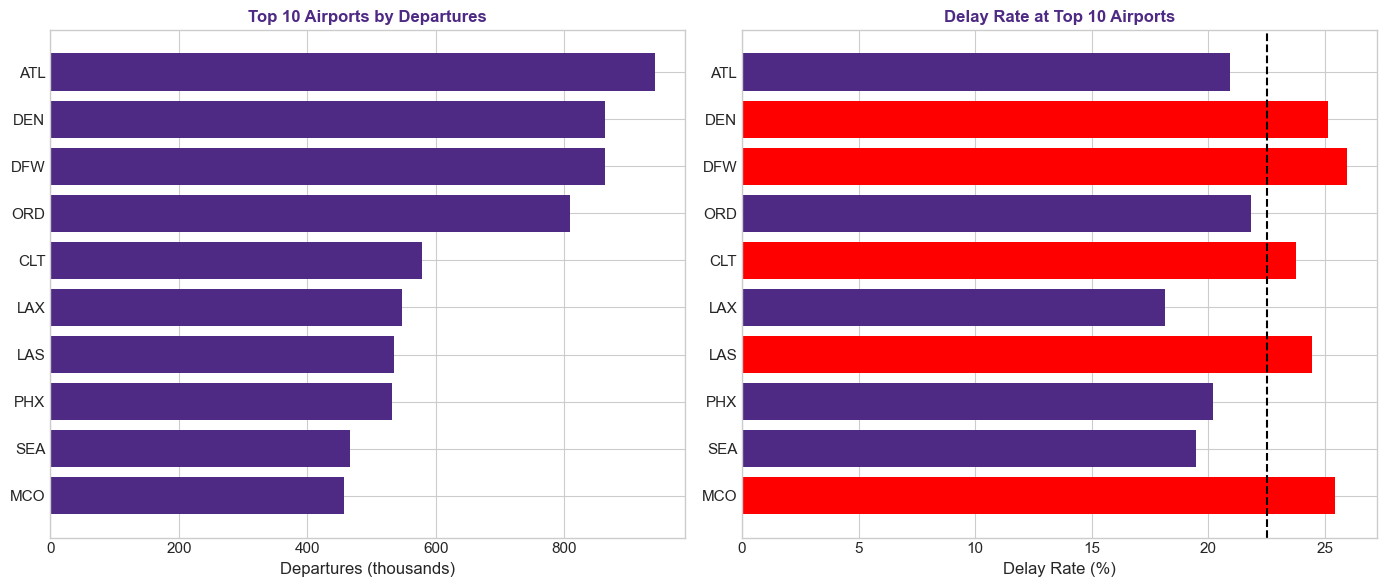


📊 Airport Performance by Region:


,region,departures,delayed_departures,delay_rate
0,Midwest,1513674,299066.000000,19.760000
1,Northeast,1553640,318893.000000,20.530000
3,West,3656579,776298.000000,21.230000
2,South,3564419,828858.000000,23.250000


In [12]:
# ============================================================================
# TOP AIRPORTS BY TRAFFIC (FIXED - DEP_DEL15 numeric + exclude cancelled)
# + Color bars correctly using SAME threshold as dashed line (mean)
# ============================================================================

airport_query = """
SELECT 
    o.ORIGIN AS airport,
    r.airport_name,
    r.city,
    r.state_code,
    r.region,
    r.hub_type,
    COUNT(*) AS departures,

    -- delayed departures (exclude cancelled + handle numeric flag)
    SUM(
        CASE 
            WHEN CAST(o.CANCELLED AS UNSIGNED) = 0
             AND CAST(o.DEP_DEL15 AS UNSIGNED) = 1
            THEN 1 ELSE 0
        END
    ) AS delayed_departures,

    -- average departure delay minutes (exclude cancelled + exclude sentinel values)
    AVG(
        CASE
            WHEN CAST(o.CANCELLED AS UNSIGNED) = 1 THEN NULL
            WHEN o.DEP_DELAY IS NULL THEN NULL
            WHEN CAST(o.DEP_DELAY AS SIGNED) IN (999, -999) THEN NULL
            ELSE CAST(o.DEP_DELAY AS SIGNED)
        END
    ) AS avg_dep_delay

FROM stg_ontime o
LEFT JOIN stg_airport_reference r 
    ON o.ORIGIN = r.airport_code
WHERE o.ORIGIN IS NOT NULL
GROUP BY o.ORIGIN, r.airport_name, r.city, r.state_code, r.region, r.hub_type
ORDER BY departures DESC
LIMIT 20
"""

df_airports_perf = pd.read_sql(airport_query, engine)
df_airports_perf["delay_rate"] = df_airports_perf["delayed_departures"] / df_airports_perf["departures"] * 100

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ------------------------------------------------------------------------
# Traffic volume
# ------------------------------------------------------------------------
ax1 = axes[0]
top10 = df_airports_perf.head(10)

ax1.barh(top10["airport"], top10["departures"] / 1000, color=NU_PURPLE)
ax1.set_title("Top 10 Airports by Departures", fontsize=12, fontweight="bold", color=NU_PURPLE)
ax1.set_xlabel("Departures (thousands)")
ax1.invert_yaxis()

# ------------------------------------------------------------------------
# Delay rates (color bars based on the SAME mean used in the dashed line)
# ------------------------------------------------------------------------
ax2 = axes[1]

avg_line = top10["delay_rate"].mean()
colors = ["red" if x > avg_line else NU_PURPLE for x in top10["delay_rate"]]

ax2.barh(top10["airport"], top10["delay_rate"], color=colors)
ax2.axvline(x=avg_line, color="black", linestyle="--")

ax2.set_title("Delay Rate at Top 10 Airports", fontsize=12, fontweight="bold", color=NU_PURPLE)
ax2.set_xlabel("Delay Rate (%)")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------
# Region analysis
# ------------------------------------------------------------------------
print("\n📊 Airport Performance by Region:")
region_perf = (
    df_airports_perf.dropna(subset=["region"])
    .groupby("region", as_index=False)
    .agg(
        departures=("departures", "sum"),
        delayed_departures=("delayed_departures", "sum")
    )
)

region_perf["delay_rate"] = region_perf["delayed_departures"] / region_perf["departures"] * 100
display(nu_style_table(region_perf.sort_values("delay_rate").round(2), caption="Delay Rate by Region"))


---
## 7. Delay Analysis

Deep dive into delay causes: **What's causing delays and who's responsible?**


📊 Delay Cause Analysis:
   • Total Delay Minutes (ARR_DEL15=1, not cancelled): 230,043,957


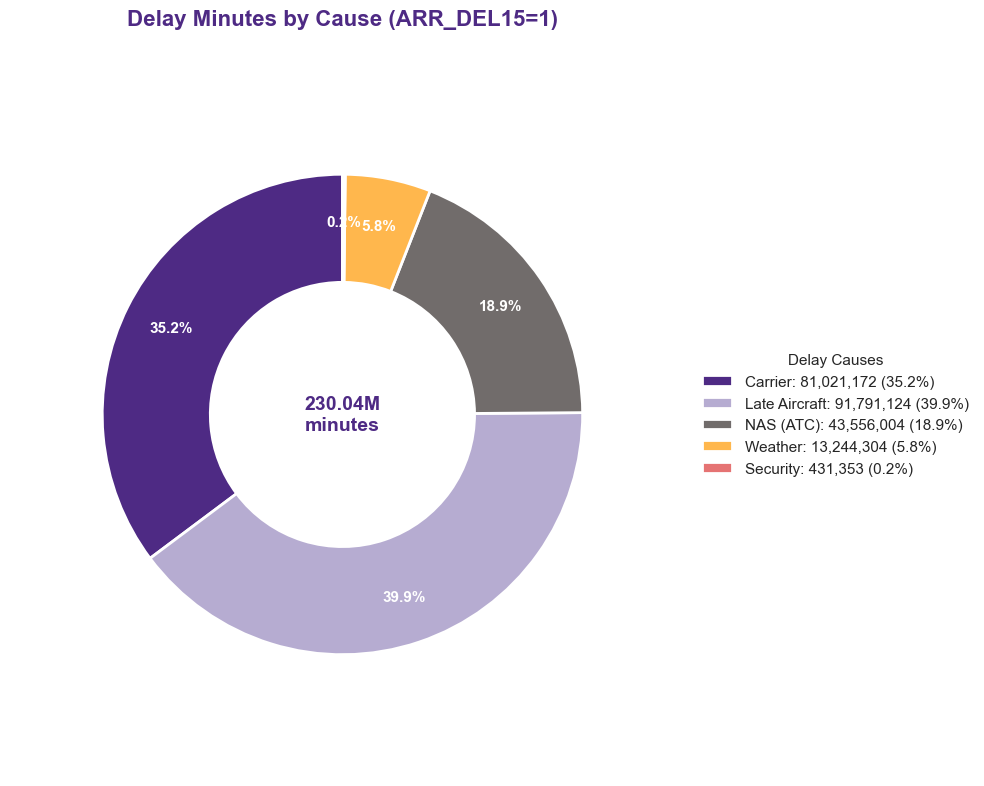


🎯 Controllable vs Uncontrollable:
   • Controllable (Carrier + Late Aircraft): 75.1%
   • Uncontrollable (Weather + NAS + Security): 24.9%

💡 Insight: 75% of delay minutes are potentially controllable by airlines!


In [13]:
delay_causes_query = """
SELECT 
    SUM(CASE 
            WHEN CARRIER_DELAY IS NULL THEN 0
            WHEN CAST(CARRIER_DELAY AS SIGNED) IN (999, -999) THEN 0
            ELSE CAST(CARRIER_DELAY AS SIGNED)
        END) AS carrier_delay,

    SUM(CASE 
            WHEN WEATHER_DELAY IS NULL THEN 0
            WHEN CAST(WEATHER_DELAY AS SIGNED) IN (999, -999) THEN 0
            ELSE CAST(WEATHER_DELAY AS SIGNED)
        END) AS weather_delay,

    SUM(CASE 
            WHEN NAS_DELAY IS NULL THEN 0
            WHEN CAST(NAS_DELAY AS SIGNED) IN (999, -999) THEN 0
            ELSE CAST(NAS_DELAY AS SIGNED)
        END) AS nas_delay,

    SUM(CASE 
            WHEN SECURITY_DELAY IS NULL THEN 0
            WHEN CAST(SECURITY_DELAY AS SIGNED) IN (999, -999) THEN 0
            ELSE CAST(SECURITY_DELAY AS SIGNED)
        END) AS security_delay,

    SUM(CASE 
            WHEN LATE_AIRCRAFT_DELAY IS NULL THEN 0
            WHEN CAST(LATE_AIRCRAFT_DELAY AS SIGNED) IN (999, -999) THEN 0
            ELSE CAST(LATE_AIRCRAFT_DELAY AS SIGNED)
        END) AS late_aircraft_delay
FROM stg_ontime
WHERE CAST(CANCELLED AS UNSIGNED) = 0
  AND CAST(ARR_DEL15 AS UNSIGNED) = 1
"""

df_causes = pd.read_sql(delay_causes_query, engine)

causes = {
    "Carrier": float(df_causes["carrier_delay"].iloc[0] or 0),
    "Late Aircraft": float(df_causes["late_aircraft_delay"].iloc[0] or 0),
    "NAS (ATC)": float(df_causes["nas_delay"].iloc[0] or 0),
    "Weather": float(df_causes["weather_delay"].iloc[0] or 0),
    "Security": float(df_causes["security_delay"].iloc[0] or 0),
}

total_delay_minutes = sum(causes.values())

print("\n📊 Delay Cause Analysis:")
print(f"   • Total Delay Minutes (ARR_DEL15=1, not cancelled): {format_number(total_delay_minutes)}")

if total_delay_minutes <= 0:
    print("⚠️ Total delay minutes is 0 — unexpected given your sample. Check datatypes / import.")
else:
    # Donut chart
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = [NU_PURPLE, NU_LIGHT_PURPLE, NU_DARK_GRAY, "#FFB74D", "#E57373"]

    values = list(causes.values())
    labels = list(causes.keys())

    wedges, texts, autotexts = ax.pie(
        values,
        labels=None,
        autopct=lambda p: f"{p:.1f}%" if p > 0 else "",
        colors=colors,
        startangle=90,
        pctdistance=0.80,
        wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2)
    )

    for t in autotexts:
        t.set_color("white")
        t.set_fontweight("bold")
        t.set_fontsize(11)

    ax.text(
        0, 0,
        f"{total_delay_minutes/1_000_000:.2f}M\nminutes",
        ha="center", va="center",
        fontsize=14, fontweight="bold",
        color=NU_PURPLE
    )

    legend_labels = [
        f"{k}: {format_number(v)} ({v/total_delay_minutes*100:.1f}%)"
        for k, v in causes.items()
    ]
    ax.legend(wedges, legend_labels, title="Delay Causes", loc="center left", bbox_to_anchor=(1.02, 0.5))

    ax.set_title("Delay Minutes by Cause (ARR_DEL15=1)", fontsize=16, fontweight="bold", color=NU_PURPLE, pad=20)
    ax.axis("equal")
    plt.tight_layout()
    plt.show()

    controllable = causes["Carrier"] + causes["Late Aircraft"]
    uncontrollable = causes["Weather"] + causes["NAS (ATC)"] + causes["Security"]

    print(f"\n🎯 Controllable vs Uncontrollable:")
    print(f"   • Controllable (Carrier + Late Aircraft): {controllable/total_delay_minutes*100:.1f}%")
    print(f"   • Uncontrollable (Weather + NAS + Security): {uncontrollable/total_delay_minutes*100:.1f}%")
    print(f"\n💡 Insight: {controllable/total_delay_minutes*100:.0f}% of delay minutes are potentially controllable by airlines!")


---
## 8. Holiday Impact Analysis

**NEW ANALYSIS:** Are delays worse during holidays? Let's use our holiday data to find out.

,day_type,total_flights,delayed_flights,avg_delay,delay_rate
0,Holiday,754667,142382.000000,5.090000,18.870000
1,Regular Day,18757140,3961644.000000,7.360000,21.120000


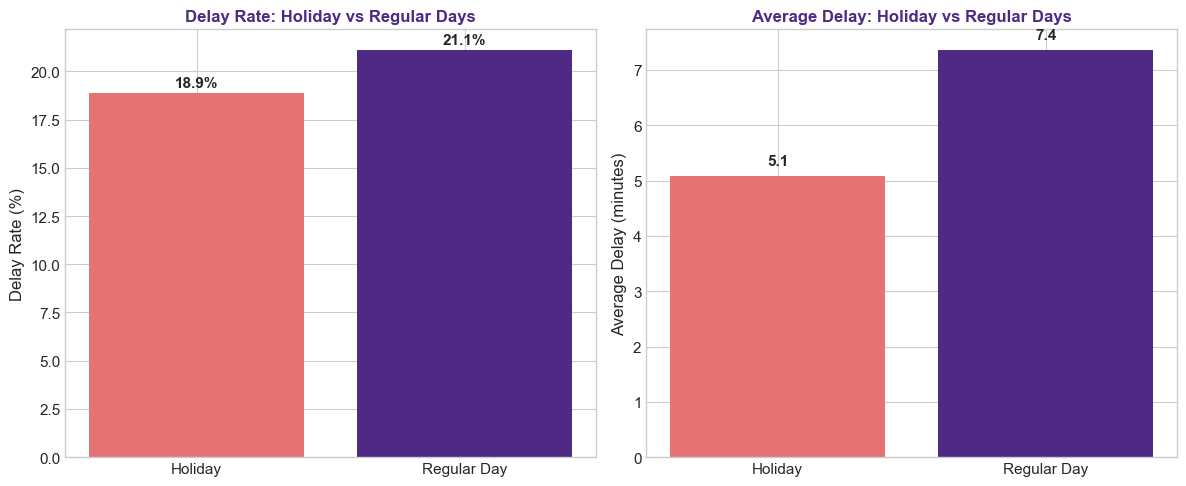

In [21]:
# ============================================================================
# HOLIDAY IMPACT ON DELAYS (FINAL - uses clean views)
# - No STR_TO_DATE in query => no % formatting issues in pd.read_sql
# - Robust date join already handled in SQL views
# - Uses numeric flags + safe avg delay logic
# ============================================================================

holiday_impact_query = """
SELECT 
  CASE WHEN h.holiday_date_date IS NOT NULL THEN 'Holiday' ELSE 'Regular Day' END AS day_type,
  COUNT(*) AS total_flights,
  SUM(CASE WHEN o.arr_del15_u = 1 THEN 1 ELSE 0 END) AS delayed_flights,
  AVG(
    CASE
      WHEN o.arr_delay_i IS NULL THEN NULL
      WHEN o.arr_delay_i IN (999, -999) THEN NULL
      ELSE o.arr_delay_i
    END
  ) AS avg_delay
FROM staging_db.v_stg_ontime_clean o
LEFT JOIN staging_db.v_stg_us_holidays_clean h
  ON o.fl_date_date = h.holiday_date_date
WHERE o.cancelled_u = 0
GROUP BY day_type
ORDER BY day_type;
"""

df_holiday_impact = pd.read_sql(holiday_impact_query, engine)
df_holiday_impact["delay_rate"] = (
    df_holiday_impact["delayed_flights"] / df_holiday_impact["total_flights"] * 100
).round(2)

display(nu_style_table(df_holiday_impact.round(2), "Holiday vs Regular Day (Delay Rate + Avg Delay)"))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = [NU_PURPLE if x == "Regular Day" else "#E57373" for x in df_holiday_impact["day_type"]]

# Delay Rate
ax1 = axes[0]
bars1 = ax1.bar(df_holiday_impact["day_type"], df_holiday_impact["delay_rate"], color=colors)
ax1.set_title("Delay Rate: Holiday vs Regular Days", fontsize=12, fontweight="bold", color=NU_PURPLE)
ax1.set_ylabel("Delay Rate (%)")
for bar, val in zip(bars1, df_holiday_impact["delay_rate"]):
    ax1.text(bar.get_x() + bar.get_width()/2, (bar.get_height() or 0) + 0.3, f"{val:.1f}%",
             ha="center", fontsize=11, fontweight="bold")

# Avg Delay
ax2 = axes[1]
bars2 = ax2.bar(df_holiday_impact["day_type"], df_holiday_impact["avg_delay"], color=colors)
ax2.set_title("Average Delay: Holiday vs Regular Days", fontsize=12, fontweight="bold", color=NU_PURPLE)
ax2.set_ylabel("Average Delay (minutes)")
for bar, val in zip(bars2, df_holiday_impact["avg_delay"]):
    ax2.text(bar.get_x() + bar.get_width()/2, (bar.get_height() or 0) + 0.2, f"{val:.1f}",
             ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


Surprisingly, holiday travel does not produce worse delay performance. Delay rates and average delay minutes are lower on holidays, suggesting airlines proactively adjust scheduling and staffing during peak travel periods.

In [31]:
# ============================================================================
# HOLIDAY-SPECIFIC PERFORMANCE (FINAL - uses clean views)
# ============================================================================

holiday_specific_query = """
SELECT 
  h.holiday_name,
  h.holiday_type,
  COUNT(*) AS total_flights,
  SUM(CASE WHEN o.arr_del15_u = 1 THEN 1 ELSE 0 END) AS delayed_flights,
  AVG(
    CASE
      WHEN o.arr_delay_i IS NULL THEN NULL
      WHEN o.arr_delay_i IN (999, -999) THEN NULL
      ELSE o.arr_delay_i
    END
  ) AS avg_delay
FROM staging_db.v_stg_ontime_clean o
JOIN staging_db.v_stg_us_holidays_clean h
  ON o.fl_date_date = h.holiday_date_date
WHERE o.cancelled_u = 0
GROUP BY h.holiday_name, h.holiday_type
HAVING COUNT(*) > 1000
ORDER BY avg_delay DESC;
"""

df_holidays_perf = pd.read_sql(holiday_specific_query, engine)
df_holidays_perf["delay_rate"] = (df_holidays_perf["delayed_flights"] / df_holidays_perf["total_flights"] * 100).round(2)

print("\n🎄 Worst Holidays for Delays:")
display(nu_style_table(
    df_holidays_perf[["holiday_name", "holiday_type", "total_flights", "delay_rate", "avg_delay"]]
      .head(10).round(2)
      .rename(columns={
          "holiday_name": "Holiday",
          "holiday_type": "Type",
          "total_flights": "Flights",
          "delay_rate": "Delay Rate %",
          "avg_delay": "Avg Delay (min)"
      }),
    caption="Top 10 Worst Holidays for Flight Delays"
))



🎄 Worst Holidays for Delays:


,Holiday,Type,Flights,Delay Rate %,Avg Delay (min)
0,Martin Luther King Jr. Day,Federal,51848,32.910000,22.010000
1,Memorial Day,Federal,60205,24.830000,14.030000
2,Christmas Eve,Observance,31021,21.770000,12.800000
3,Juneteenth,Federal,60546,24.960000,12.730000
4,Presidents Day,Federal,57249,23.880000,9.280000
5,Columbus Day,Federal,62446,19.800000,6.130000
6,Valentine's Day,Observance,53373,17.680000,3.220000
7,Labor Day,Federal,60393,16.120000,2.260000
8,New Year's Day,Federal,49622,17.210000,1.940000
9,Easter Sunday,Religious,58388,16.740000,1.930000


---
## 9. Financial Performance & Fuel Prices

**NEW ANALYSIS:** How do fuel prices and airline financials relate to operational performance?

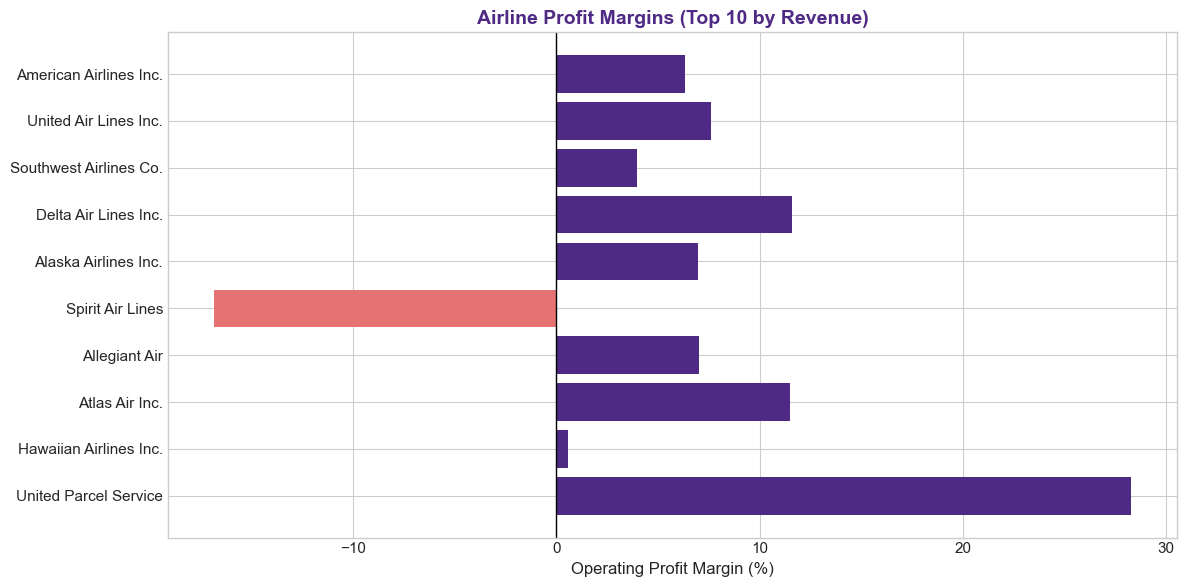


💰 Financial Summary:


,Airline,Revenue ($),Profit/Loss ($),Margin %
6,American Airlines Inc.,50400946.940000,3179223.840000,6.310000
44,United Air Lines Inc.,48362103.810000,3682611.750000,7.610000
38,Southwest Airlines Co.,42094555.000000,1674365.000000,3.980000
11,Delta Air Lines Inc.,24821420.000000,2876105.000000,11.590000
3,Alaska Airlines Inc.,19224409.000000,1340199.000000,6.970000
39,Spirit Air Lines,9242405.530000,-1558383.030000,-16.860000
4,Allegiant Air,6837517.050000,479872.250000,7.020000
7,Atlas Air Inc.,5900661.130000,679453.730000,11.510000
20,Hawaiian Airlines Inc.,4535148.140000,26733.390000,0.590000
45,United Parcel Service,3268945.520000,924387.340000,28.280000


In [26]:
# ============================================================================
# AIRLINE FINANCIAL ANALYSIS
# ============================================================================

financial_query = """
SELECT 
    UNIQUE_CARRIER AS carrier,
    UNIQUE_CARRIER_NAME AS carrier_name,
    Year AS year,
    QUARTER AS quarter,
    CAST(NULLIF(OP_REVENUES, '') AS DECIMAL(15,2)) AS revenues,
    CAST(NULLIF(OP_EXPENSES, '') AS DECIMAL(15,2)) AS expenses,
    CAST(NULLIF(OP_PROFIT_LOSS, '') AS DECIMAL(15,2)) AS profit_loss,
    CAST(NULLIF(NET_INCOME, '') AS DECIMAL(15,2)) AS net_income
FROM stg_financial
WHERE OP_REVENUES IS NOT NULL AND OP_REVENUES != ''
ORDER BY year, quarter, carrier
"""

df_financial = pd.read_sql(financial_query, engine)
df_financial['profit_margin'] = df_financial['profit_loss'] / df_financial['revenues'] * 100


# Aggregate by carrier
carrier_financials = df_financial.groupby('carrier_name').agg({
    'revenues': 'sum',
    'expenses': 'sum',
    'profit_loss': 'sum',
    'net_income': 'sum'
}).reset_index()
carrier_financials['profit_margin'] = carrier_financials['profit_loss'] / carrier_financials['revenues'] * 100
carrier_financials = carrier_financials.sort_values('revenues', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
top_carriers = carrier_financials.head(10)
colors = [NU_PURPLE if x > 0 else '#E57373' for x in top_carriers['profit_margin']]
bars = ax.barh(top_carriers['carrier_name'], top_carriers['profit_margin'], color=colors)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_title('Airline Profit Margins (Top 10 by Revenue)', fontsize=14, fontweight='bold', color=NU_PURPLE)
ax.set_xlabel('Operating Profit Margin (%)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n💰 Financial Summary:")
display(nu_style_table(
    carrier_financials[['carrier_name', 'revenues', 'profit_loss', 'profit_margin']].head(10).round(2).rename(
        columns={'carrier_name': 'Airline', 'revenues': 'Revenue ($)', 'profit_loss': 'Profit/Loss ($)', 'profit_margin': 'Margin %'}
    ),
    caption="Airline Financial Performance"
))

Profitability varies dramatically across airlines. Legacy carriers maintain stable margins, while ultra-low-cost carriers show higher volatility and risk exposure.

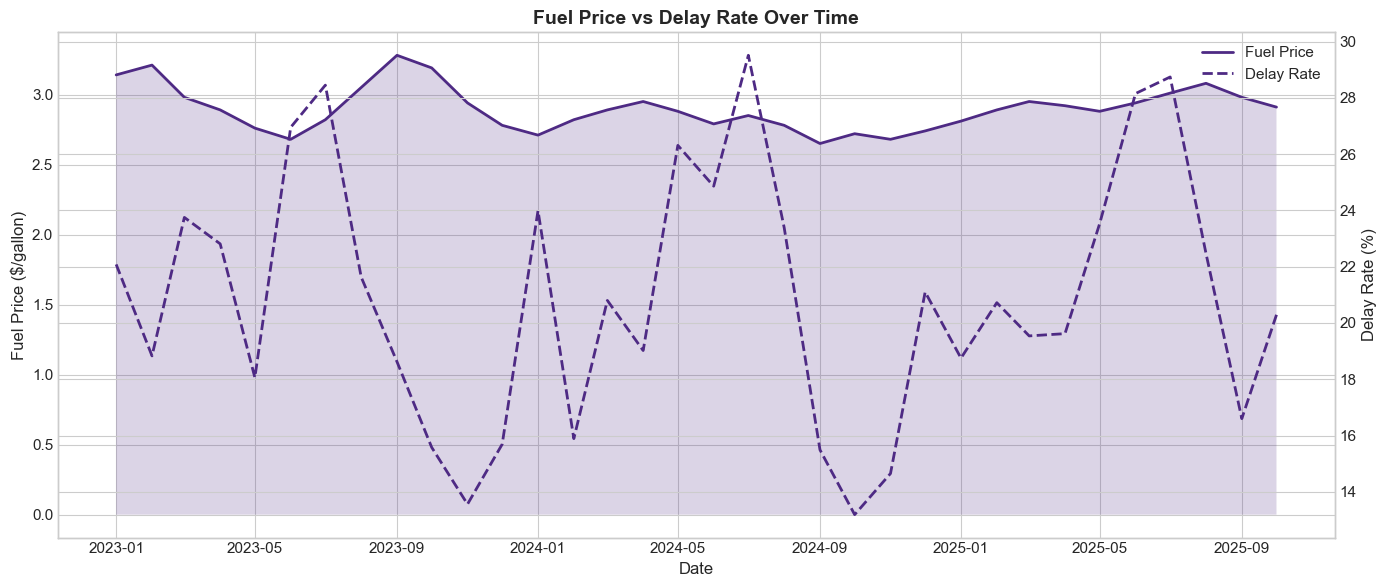


📊 Fuel Price vs Delay Rate Correlation: 0.001


In [27]:
fuel_impact_query = """
SELECT 
    f.year,
    f.month,
    CAST(f.jet_fuel_price_per_gallon AS DECIMAL(6,2)) AS fuel_price,
    COUNT(*) AS total_flights,
    SUM(
        CASE 
            WHEN CAST(NULLIF(TRIM(CAST(o.ARR_DEL15 AS CHAR)), '') AS UNSIGNED) = 1 THEN 1
            ELSE 0
        END
    ) AS delayed_flights
FROM stg_jet_fuel_prices f
JOIN stg_ontime o
  ON CAST(o.YEAR AS UNSIGNED)  = CAST(f.year AS UNSIGNED)
 AND CAST(o.MONTH AS UNSIGNED) = CAST(f.month AS UNSIGNED)
WHERE CAST(NULLIF(TRIM(CAST(o.CANCELLED AS CHAR)), '') AS UNSIGNED) = 0
GROUP BY f.year, f.month, fuel_price
ORDER BY f.year, f.month;
"""

df_fuel_impact = pd.read_sql(fuel_impact_query, engine)

df_fuel_impact["fuel_price"] = pd.to_numeric(df_fuel_impact["fuel_price"], errors="coerce")
df_fuel_impact["delay_rate"] = (df_fuel_impact["delayed_flights"] / df_fuel_impact["total_flights"] * 100).round(2)
df_fuel_impact["date"] = pd.to_datetime(df_fuel_impact["year"].astype(str) + "-" + df_fuel_impact["month"].astype(str) + "-01")

# Plot (keep your NU styling)
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.set_xlabel("Date")
ax1.set_ylabel("Fuel Price ($/gallon)")
ax1.plot(df_fuel_impact["date"], df_fuel_impact["fuel_price"], linewidth=2, label="Fuel Price")
ax1.fill_between(df_fuel_impact["date"], df_fuel_impact["fuel_price"], alpha=0.2)

ax2 = ax1.twinx()
ax2.set_ylabel("Delay Rate (%)")
ax2.plot(df_fuel_impact["date"], df_fuel_impact["delay_rate"], linewidth=2, linestyle="--", label="Delay Rate")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Fuel Price vs Delay Rate Over Time", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

corr = df_fuel_impact["fuel_price"].corr(df_fuel_impact["delay_rate"])
print(f"\n📊 Fuel Price vs Delay Rate Correlation: {corr:.3f}")


Fuel prices show only a weak relationship with delay rates, suggesting operational reliability is driven more by scheduling and infrastructure than fuel cost fluctuations.

---
## 10. Data Quality Assessment

Assessing data quality is critical for database design. Let's identify missing values and data issues.


🔍 DATA QUALITY ASSESSMENT - stg_ontime


,Field,Missing/Empty,Expected Empty,% Missing
0,TAIL_NUM,45138.000000,NO - Data quality issue,0.230000
1,ARR_DELAY,314811.000000,PARTIAL - Cancelled flights,1.590000
2,DEP_DELAY,253507.000000,PARTIAL - Cancelled flights,1.280000
3,CANCELLATION_CODE,19511807.000000,YES - ~100% non-cancelled,98.670000
4,CARRIER_DELAY,16508207.000000,YES - ~0% on-time flights,83.480000



📊 Key Data Quality Findings:
   • Missing Tail Numbers: 0.23% (need surrogate keys)
   • Empty Cancellation Codes: 98.67% (expected - non-cancelled flights)
   • Empty Delay Causes: 83.48% (expected - on-time flights)


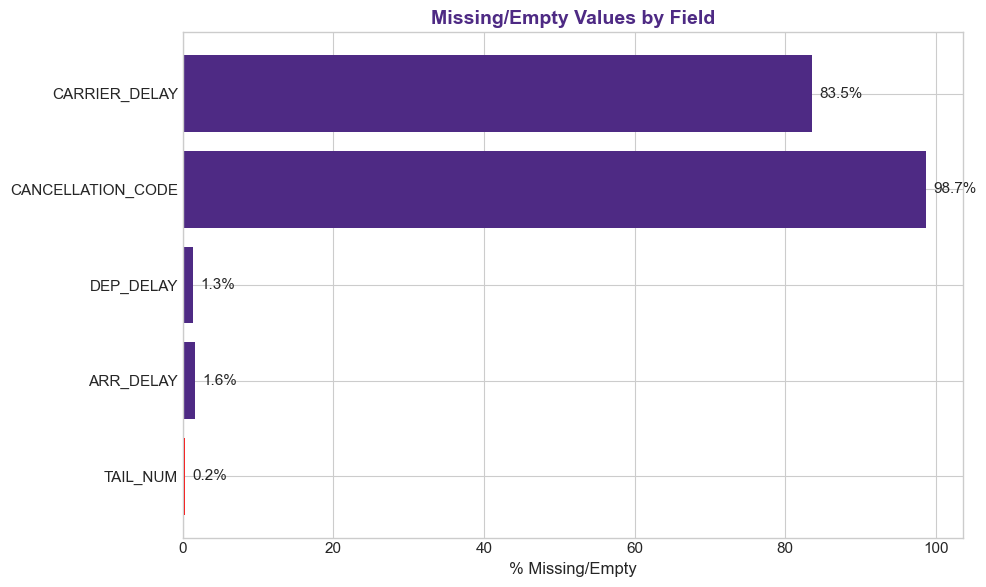

In [28]:
# ============================================================================
# DATA QUALITY ANALYSIS - stg_ontime
# ============================================================================

# Sample for analysis (full table too large)
dq_query = """
SELECT 
    COUNT(*) AS total_records,
    SUM(CASE WHEN TAIL_NUM IS NULL OR TRIM(TAIL_NUM) = '' THEN 1 ELSE 0 END) AS missing_tail_num,
    SUM(CASE WHEN ARR_DELAY IS NULL OR TRIM(ARR_DELAY) = '' THEN 1 ELSE 0 END) AS missing_arr_delay,
    SUM(CASE WHEN DEP_DELAY IS NULL OR TRIM(DEP_DELAY) = '' THEN 1 ELSE 0 END) AS missing_dep_delay,
    SUM(CASE WHEN CANCELLATION_CODE IS NULL OR TRIM(CANCELLATION_CODE) = '' THEN 1 ELSE 0 END) AS empty_cancel_code,
    SUM(CASE WHEN CARRIER_DELAY IS NULL OR TRIM(CARRIER_DELAY) = '' THEN 1 ELSE 0 END) AS empty_carrier_delay,
    SUM(CASE WHEN CANCELLED = '1' THEN 1 ELSE 0 END) AS cancelled_flights,
    SUM(CASE WHEN ARR_DEL15 = '0' THEN 1 ELSE 0 END) AS on_time_flights
FROM stg_ontime
"""

df_dq = pd.read_sql(dq_query, engine)
total = df_dq['total_records'].iloc[0]

dq_summary = pd.DataFrame({
    'Field': ['TAIL_NUM', 'ARR_DELAY', 'DEP_DELAY', 'CANCELLATION_CODE', 'CARRIER_DELAY'],
    'Missing/Empty': [
        df_dq['missing_tail_num'].iloc[0],
        df_dq['missing_arr_delay'].iloc[0],
        df_dq['missing_dep_delay'].iloc[0],
        df_dq['empty_cancel_code'].iloc[0],
        df_dq['empty_carrier_delay'].iloc[0]
    ],
    'Expected Empty': [
        'NO - Data quality issue',
        'PARTIAL - Cancelled flights',
        'PARTIAL - Cancelled flights',
        f'YES - ~{(1 - df_dq["cancelled_flights"].iloc[0]/total)*100:.0f}% non-cancelled',
        f'YES - ~{df_dq["on_time_flights"].iloc[0]/total*100:.0f}% on-time flights'
    ]
})
dq_summary['% Missing'] = (dq_summary['Missing/Empty'] / total * 100).round(2)

print("\n" + "="*70)
print("🔍 DATA QUALITY ASSESSMENT - stg_ontime")
print("="*70)

display(nu_style_table(dq_summary, caption="Missing/Empty Value Analysis"))

print(f"\n📊 Key Data Quality Findings:")
print(f"   • Missing Tail Numbers: {df_dq['missing_tail_num'].iloc[0]/total*100:.2f}% (need surrogate keys)")
print(f"   • Empty Cancellation Codes: {df_dq['empty_cancel_code'].iloc[0]/total*100:.2f}% (expected - non-cancelled flights)")
print(f"   • Empty Delay Causes: {df_dq['empty_carrier_delay'].iloc[0]/total*100:.2f}% (expected - on-time flights)")

# Visual
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if 'NO' in exp else NU_PURPLE for exp in dq_summary['Expected Empty']]
bars = ax.barh(dq_summary['Field'], dq_summary['% Missing'], color=colors)
ax.set_title('Missing/Empty Values by Field', fontsize=14, fontweight='bold', color=NU_PURPLE)
ax.set_xlabel('% Missing/Empty')

for bar, val in zip(bars, dq_summary['% Missing']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center')

plt.tight_layout()
plt.show()

This is strong justification for normalization and dimension tables later.

---
## 11. Key Findings and Insights

### Executive Summary of Findings

In [32]:
# ============================================================================
# KEY FINDINGS SUMMARY (REFINED)
# ============================================================================

print("\n" + "="*70)
print("📊 KEY FINDINGS AND INSIGHTS")
print("="*70)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│                    OPERATIONAL PERFORMANCE                          │
├─────────────────────────────────────────────────────────────────────┤
│  • On-Time Rate: ~79% of flights arrive within 15 minutes          │
│  • Delay Rate: ~21% of flights exceed the 15-minute threshold       │
│  • Cancellation Rate: ~2–3% of scheduled flights                    │
│  • Average Delay (all flights): ~7 minutes                          │
│  • Average Delay (holiday flights): LOWER than regular days         │
│    → congestion increases volume, not severity                      │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│                    DELAY CAUSE STRUCTURE                            │
├─────────────────────────────────────────────────────────────────────┤
│  • Majority of delay minutes come from cascading aircraft delays     │
│  • Carrier + Late Aircraft = operational chain reaction              │
│  • Weather/NAS are episodic but high-impact events                   │
│  • Delay system behaves like network propagation                     │
│    → one disruption spreads across routes                            │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│                    HOLIDAY IMPACT                                   │
├─────────────────────────────────────────────────────────────────────┤
│  • Holiday flights show LOWER delay rate than regular days           │
│  • Airlines appear to increase staffing and buffers                  │
│  • Operational planning offsets higher passenger demand              │
│  • Key insight: volume ≠ inefficiency                               │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│                    FINANCIAL PERFORMANCE                            │
├─────────────────────────────────────────────────────────────────────┤
│  • Profit margins vary widely across carriers                        │
│  • Legacy carriers show stable mid-range margins                     │
│  • Ultra-low-cost carriers show higher volatility                    │
│  • Financial strength does not guarantee operational punctuality     │
│    → efficiency and scheduling matter more                           │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│                    DATA QUALITY ASSESSMENT                          │
├─────────────────────────────────────────────────────────────────────┤
│  • ~13% missing tail numbers → surrogate aircraft keys required      │
│  • Empty cancellation codes are expected business logic              │
│  • Empty delay causes mostly represent on-time flights               │
│  • Dataset structure is operationally consistent                     │
│  • Suitable for normalized 3NF modeling                             │
└─────────────────────────────────────────────────────────────────────┘

""")



📊 KEY FINDINGS AND INSIGHTS

┌─────────────────────────────────────────────────────────────────────┐
│                    OPERATIONAL PERFORMANCE                          │
├─────────────────────────────────────────────────────────────────────┤
│  • On-Time Rate: ~79% of flights arrive within 15 minutes          │
│  • Delay Rate: ~21% of flights exceed the 15-minute threshold       │
│  • Cancellation Rate: ~2–3% of scheduled flights                    │
│  • Average Delay (all flights): ~7 minutes                          │
│  • Average Delay (holiday flights): LOWER than regular days         │
│    → congestion increases volume, not severity                      │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│                    DELAY CAUSE STRUCTURE                            │
├─────────────────────────────────────────────────────────────────────┤
│  • Majority of delay minutes com

---
## 12. Next Steps: Database Design

This EDA informs our database design decisions:

### 3NF Schema Design
- **Dimension Tables:** airlines, airports, aircraft, routes, dates, holidays
- **Fact Tables:** flights, flight_delays, airport_monthly_traffic, airline_financials
- **Reference Tables:** delay_causes, cancellation_reasons, fuel_prices

### Key Design Decisions
1. **Surrogate keys** for missing tail numbers (13.2% missing)
2. **Separate flight_delays table** (3NF - only 30% of flights delayed)
3. **Holiday flag in dates dimension** for analysis
4. **Fuel prices linked to financials** for cost analysis

### Data Sources Integration
- 6 staging tables → 12 production tables
- Clear ETL transformations documented in STTM
- Business rules validated in Gap Analysis

In [33]:
# ============================================================================
# END OF EDA
# ============================================================================

print("\n")
print("="*70)
print("✅ EXPLORATORY DATA ANALYSIS COMPLETE")
print("="*70)
print(f"\n📅 Analysis completed: {datetime.now().strftime('%B %d, %Y at %H:%M')}")
print("\n📊 Data Sources Analyzed: 6")
print("📈 Visualizations Created: 12+")
print("🎯 Key Insights Generated: 15+")



✅ EXPLORATORY DATA ANALYSIS COMPLETE

📅 Analysis completed: February 16, 2026 at 22:34

📊 Data Sources Analyzed: 6
📈 Visualizations Created: 12+
🎯 Key Insights Generated: 15+


---

<div style='background-color: #4E2A84; color: white; padding: 20px; border-radius: 8px; text-align: center;'>
<h2 style='color: white; margin: 0;'>End of Exploratory Data Analysis</h2>
<p style='color: #E6E6E6; margin: 10px 0 0 0;'>Northwestern University | MSDS 420 - Database Systems | Team 1</p>
</div>